In [1]:
import os
from locscale.include.emmer.ndimage.map_utils import load_map, save_as_mrc 
import numpy as np 
import matplotlib.pyplot as plt

unsharpened_map_path = "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/emd_0665/EMD_665_unsharpened_fullmap.mrc"
feature_enhanced_map_path = "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/emd_0665/feature_enhance/emd_0665_feature_enhanced_mean.mrc"
deepemhancer_map_path = "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/emd_0665/deepemhancer/emd_0665_deepemhancer.mrc"
emready_map_path = "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/emd_0665/emready/emd_0665_emready_resampled.mrc"
mask_path = "/home/abharadwaj1/papers/elife_paper/figure_information/data/confidence_masks/emd_0665_FDR_confidence_final.map"

unsharpened_map, apix = load_map(unsharpened_map_path)
feature_enhanced_map, apix = load_map(feature_enhanced_map_path)
deepemhancer_map, apix = load_map(deepemhancer_map_path)
emready_map, apix = load_map(emready_map_path)
mask, apix = load_map(mask_path)

mask_binarized = np.where(mask > 0.99, 1, 0)



In [3]:
import os 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from locscale.include.emmer.ndimage.fsc_util import calculate_phase_correlation_maps 
from locscale.include.emmer.ndimage.map_utils import load_map, save_as_mrc
from locscale.include.emmer.ndimage.filter import get_cosine_mask
from tqdm import tqdm

# unsharpened_map_path = "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/emd_0665/EMD_665_unsharpened_fullmap.mrc"
# feature_enhanced_map_path = "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/emd_0665/feature_enhance/emd_0665_feature_enhanced_mean.mrc"
# deepemhancer_map_path = "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/emd_0665/deepemhancer/emd_0665_deepemhancer.mrc"
# emready_map_path = "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/emd_0665/emready/emd_0665_emready_resampled.mrc"
# mask_path = "/home/abharadwaj1/papers/elife_paper/figure_information/data/confidence_masks/emd_0665_FDR_confidence_final.map"

# unsharpened_map_path = "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/emd_33888/processing_files/EMD_33888_unsharpened_fullmap.mrc"
# feature_enhanced_map_path = "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/emd_33888/emd_33888_feature_enhanced_map_mean.mrc"
# deepemhancer_map_path = "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/emd_33888/deepemhancer/emd_33888.map"
# emready_map_path = "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/emd_33888/emready/emd_33888_emready.mrc"
# mask_path = "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/emd_33888/processing_files/EMD_33888_unsharpened_fullmap_confidenceMap_raw.mrc"

# unsharpened_map_path = "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/sub_tomogram_analysis/emd_13234/EMD_13234_unsharpened_fullmap.mrc"
# feature_enhanced_map_path = "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/sub_tomogram_analysis/emd_13234/feature_enhance/emd_13234_feature_enhance_mean.mrc"
# deepemhancer_map_path = "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/sub_tomogram_analysis/emd_13234/deepemhancer/emd_13234_deepemhancer_wide.mrc"
# emready_map_path = "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/sub_tomogram_analysis/emd_13234/emready/emd_13234_emready.mrc"
# mask_path = "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/sub_tomogram_analysis/emd_13234/EMD_13234_unsharpened_fullmap_confidenceMap_custom_loc_5A.mrc"
EMDB_PDB_ids_epsilon = ["0282_6huo", "0311_6hz5", "0560_6nzu", "10365_6t23", "20220_6oxl", "20226_6p07", "3545_5mqf", "4141_5m1s", "4531_6qdw", "4571_6qk7", "4997_6rtc", "7127_6bpq",  "8702_5vkq", "9610_6adq"]

parent_dir = "/home/abharadwaj1/papers/elife_paper/figure_information/"
feature_enhance_parent_folder = os.path.join(parent_dir, "outputs","feature_enhance_test_maps_hybrid_60k")
deepemhancer_parent_folder = os.path.join(parent_dir, "data","deepemhancer_maps_test")
emready_parent_folder = os.path.join(parent_dir, "outputs","emready_outputs")
mask_parent_folder = os.path.join(parent_dir, "data","confidence_masks")
dump_all_data = os.path.join(parent_dir, "data","compute_cii_all_data")
os.makedirs(dump_all_data, exist_ok=True)
input_files_emdb = {}
for emdb_pdb in EMDB_PDB_ids_epsilon:
    emdb, pdb = emdb_pdb.split("_")
    unsharpened_map_path = os.path.join(feature_enhance_parent_folder,f"{emdb_pdb}", f"EMD_{int(emdb)}_unsharpened_fullmap.mrc")
    feature_enhanced_map_path = os.path.join(feature_enhance_parent_folder, f"{emdb_pdb}", f"emd_{emdb}_emmernet_output_mean.mrc")
    deepemhancer_map_path = os.path.join(deepemhancer_parent_folder, f"{emdb_pdb}", f"emd_{emdb}_DeepEMhancer_wideTarget.map")
    emready_map_path = os.path.join(emready_parent_folder,f"{emdb_pdb}", f"emd_{emdb}_emready_output.mrc")
    mask_path = os.path.join(mask_parent_folder, f"emd_{emdb}_FDR_confidence_final.map")

    filenames_list = [mask_path, unsharpened_map_path, feature_enhanced_map_path, deepemhancer_map_path, emready_map_path]
    if not all([os.path.exists(filename) for filename in filenames_list]):
        # print which files are missing
        for filename in filenames_list:
            if not os.path.exists(filename):
                print(f"{filename} does not exist")

        continue

    input_files_emdb[emdb_pdb] = filenames_list

emdb_ids_to_add = ["0193", "51108", "44469", "15949", "12654", "19999", "0406", "7770", "35193", "8949", "22358", "41485", "17316", "39112", "39109"]

input_files_emdb["0193_6hcg"] = [
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/emd_0193/using_60k_cubes_fullnetwork/emd_0193_FDR_confidence_final.map",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/emd_0193/using_60k_cubes_fullnetwork/EMD_193_unsharpened_fullmap.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/emd_0193/emd_0193_model_free_filtered_dataset_prediction_symmetrised/emd_0193_model_free_predicted_ref.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/emd_0193/deepemhancer/emd_0193_deepemhancer.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/emd_0193/emready/emd_0193_emready.mrc",
]
input_files_emdb["51108_xxxx"] = [
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/transmembrane/emd_51108/processing_files/EMD_51108_unsharpened_fullmap_confidenceMap.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/transmembrane/emd_51108/processing_files/EMD_51108_unsharpened_fullmap.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/transmembrane/emd_51108/emd_51108_fe.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/transmembrane/emd_51108/emd_51108_deepemhancer.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/transmembrane/emd_51108/emd_51108_emready.mrc"
]
input_files_emdb["44469_xxxx"] = [
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/emd_44469/processing_files/EMD_44469_unsharpened_fullmap_confidenceMap.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/emd_44469/processing_files/EMD_44469_unsharpened_fullmap.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/emd_44469/emd_44469_fe.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/emd_44469/deepemhancer/emd_44469_deepemhancer.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/emd_44469/emready/emd_44468_emready.mrc",
]
input_files_emdb["15949_xxxx"] = [
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/sub_tomogram_analysis/new_sta_maps/emd_15949/emd_15949_unsharpened_confidenceMap.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/sub_tomogram_analysis/new_sta_maps/emd_15949/processing_files/EMD_15949_unsharpened_fullmap.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/sub_tomogram_analysis/new_sta_maps/emd_15949/feature_enhanced_output.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/emd_15949/deepemhancer/emd_15949_deepemhancer.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/sub_tomogram_analysis/new_sta_maps/emd_15949/emready/emd_15949_emready.mrc",
]
input_files_emdb["12654_xxxx"] = [
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/emd_12654/EMD_12654_unsharpened_fullmap_confidenceMap.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/emd_12654/fe/processing_files/EMD_12654_unsharpened_fullmap.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/emd_12654/fe/emmernet_output_feature_enhanced_output.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/emd_12654/deepemhancer/emd_12654_deepemhancer.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/emd_12654/emready/emd_12654_emready.mrc",
]
input_files_emdb["19999_xxxx"] = [
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/sub_tomogram_analysis/new_sta_maps/emd_19999/processing_files/emd_19999_unsharpened_confidenceMap.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/sub_tomogram_analysis/new_sta_maps/emd_19999/processing_files/EMD_19999_unsharpened_fullmap.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/sub_tomogram_analysis/new_sta_maps/emd_19999/feature_enhanced_output_C2_symmetrized.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-19999/emd_19999_deepEMhancer_map.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-19999/emd_19999_EMReady_map.mrc",
]
input_files_emdb["0406_xxxx"] = [
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-0406/emd_0406_unsharpened_confidenceMap.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-0406/emd_0406_unsharpened.map",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-0406/emd_0406_unsharpened_model_map_predicted.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-0406/emd_0406_deepEMhancer_map.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-0406/emd_0406_EMReady_map.mrc",
]
input_files_emdb["7770_xxxx"] = [
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-7770/emd_7770_unsharpened_confidenceMap.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-7770/emd_7770_unsharpened.map",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-7770/emd_7770_unsharpened_model_map_predicted.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-7770/emd_7770_deepEMhancer_map.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-7770/emd_7770_EMReady_map.mrc",
]
input_files_emdb["35193_xxxx"] = [
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-35193/emd_35193_unsharpened_confidenceMap.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-35193/emd_35193_unsharpened.map",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-35193/emd_35193_unsharpened_model_map_predicted.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-35193/emd_35193_deepEMhancer_map.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-35193/emd_35193_EMReady_map.mrc",
]
input_files_emdb["8949_xxxx"] = [
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-8949/emd_8949_unsharpened_confidenceMap.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-8949/emd_8949_unsharpened.map",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-8949/emd_8949_unsharpened_model_map_predicted.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-8949/emd_8949_deepEMhancer_map.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-8949/emd_8949_EMReady_map.mrc",
]
input_files_emdb["22358_xxxx"] = [
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-22358/emd_22358_unsharpened_confidenceMap.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-22358/emd_22358_unsharpened.map",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-22358/emd_22358_unsharpened_model_map_predicted.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-22358/emd_22358_deepEMhancer_map.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-22358/emd_22358_EMReady_map.mrc",
]
input_files_emdb["41485_xxxx"] = [
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-41485/emd_41485_unsharpened_confidenceMap.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-41485/emd_41485_unsharpened.map",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-41485/emd_41485_unsharpened_model_map_predicted.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-41485/emd_41485_deepEMhancer_map.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-41485/emd_41485_EMReady_map.mrc",
]
input_files_emdb["17316_xxxx"] = [
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-17316/emd_17316_unsharpened_confidenceMap.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-17316/emd_17316_unsharpened.map",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-17316/emd_17316_unsharpened_model_map_predicted.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-17316/emd_17316_deepEMhancer_map.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-17316/emd_17316_EMReady_map.mrc",
]
input_files_emdb["39112_xxxx"] = [
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-39112/emd_39112_unsharpened_confidenceMap.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-39112/emd_39112_unsharpened.map",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-39112/emd_39112_unsharpened_model_map_predicted.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-39112/emd_39112_deepEMhancer_map.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-39112/emd_39112_EMReady_map.mrc",
]
input_files_emdb["39109_xxxx"] = [
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-39109/emd_39109_unsharpened_confidenceMap.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-39109/emd_39109_unsharpened.map",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-39109/emd_39109_unsharpened_model_map_predicted.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-39109/emd_39109_deepEMhancer_map.mrc",
    "/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii/EMD-39109/emd_39109_EMReady_map.mrc",
]

# drop any key which has a missing file 
for emdb_pdb in list(input_files_emdb.keys()):
    if not all([os.path.exists(filename) for filename in input_files_emdb[emdb_pdb]]):
        print(f"Missing files for {emdb_pdb}")
        del input_files_emdb[emdb_pdb]
           
def get_recall_curve(emmap_path, mask_path, threshold=0.99):
    from locscale.include.emmer.ndimage.map_utils import load_map, save_as_mrc
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import precision_recall_curve
    from scipy.interpolate import interp1d

    emmap, apix = load_map(emmap_path)
    mask, apix = load_map(mask_path)
    mask_binarized = np.where(mask > threshold, 1, 0)

    emmap_positive = np.zeros(emmap.shape)
    emmap_positive[emmap > 0] = emmap[emmap > 0]
    print(emmap.shape)
    emmap_positive_rescaled = (emmap_positive - emmap_positive.min()) / (emmap_positive.max() - emmap_positive.min())
    
    precisions, recall, thresholds = precision_recall_curve(mask_binarized.flatten(), emmap_positive_rescaled.flatten())

    thresholds_new_range = np.linspace(thresholds.min(), thresholds.max(), 1000)
    f = interp1d(thresholds, recall[:-1])
    recall_new_range = f(thresholds_new_range)

    # calculate the area under the curve
    auc = np.trapz(recall_new_range, thresholds_new_range)
    contextual_information_index = auc 

    return recall_new_range, thresholds_new_range, contextual_information_index


def compare_recall_curves(mask_path, unsharpened_map_path, *map_paths):
    from locscale.include.emmer.ndimage.map_utils import resample_map
    
    masked_maps = {}
    unsharpened_map, apix = load_map(unsharpened_map_path)
    for emmap_path in map_paths:
        emmap_filename = os.path.basename(emmap_path)
        emmap, apix_map = load_map(emmap_path)
        if apix_map != apix:
            emmap = resample_map(emmap, apix=apix_map, apix_new=apix, assert_shape=unsharpened_map.shape, order=3)
            emmap_path = emmap_path.replace(".mrc", "_resampled.mrc")
            save_as_mrc(emmap, emmap_path, apix=apix)
            
        masked_maps[emmap_filename] = emmap_path


    recall_curves = {}
    for emmap_filename, emmap_path in masked_maps.items():
        recall_curves[emmap_filename] = get_recall_curve(emmap_path, mask_path)
    
    return recall_curves

print(f"Number of datasets to process: {len(input_files_emdb)}")

/home/abharadwaj1/papers/elife_paper/figure_information/outputs/emready_outputs/0311_6hz5/emd_0311_emready_output.mrc does not exist
Missing files for 17316_xxxx
Number of datasets to process: 27


In [14]:
import pandas as pd
model_angelo_training_dataset = "/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/processed/pdbs/figure_7/modelangelo_training_dataset.csv"
model_angelo_training_ids = pd.read_csv(model_angelo_training_dataset)
model_angelo_training_emdbs = model_angelo_training_ids["EMDB Map"].tolist()
emdb_in_model_angelo_training = [x.split("-")[1] for x in model_angelo_training_emdbs]

emdb_part_of_new_dataset = lambda emdb: emdb in os.listdir("/home/abharadwaj1/papers/elife_paper/figure_information/data/model_angelo_using_new_dataset/model_angelo_predictions")

In [18]:
for emdb_pdb in input_files_emdb.keys():
    emdb, pdb = emdb_pdb.split("_")
    # if emdb_pdb in EMDB_PDB_ids_epsilon:
    #     #print(f"{emdb} is in epsilon test set")
    #     pass
    # if emdb in emdb_in_model_angelo_training:
    #     #print(f"{emdb} is in model angelo training set")
    #     pass
    
    if pdb == "xxxx":
        print(f"{emdb} is an additional dataset" )
        
        


51108 is an additional dataset
44469 is an additional dataset
15949 is an additional dataset
12654 is an additional dataset
19999 is an additional dataset
0406 is an additional dataset
7770 is an additional dataset
35193 is an additional dataset
8949 is an additional dataset
22358 is an additional dataset
41485 is an additional dataset
39112 is an additional dataset
39109 is an additional dataset


In [3]:
def emdb_to_pdb(emdb_id):
    import requests    
    url = f"https://www.ebi.ac.uk/emdb/api/entry/{emdb_id}"
    response = requests.get(url)
    data = response.json()
    try:
        pdb_id = data["crossreferences"]["pdb_list"]["pdb_reference"][0]["pdb_id"]

        return pdb_id    
    except (KeyError, IndexError):
        print(f"No PDB ID found for EMDB ID {emdb_id}")
        return "none"

In [4]:
from locscale.include.emmer.ndimage.map_tools import get_atomic_model_mask, find_unmodelled_mask_region
from locscale.include.emmer.ndimage.map_utils import load_map, save_as_mrc
from locscale.include.emmer.pdb.pdb_utils import get_gemmi_st_from_id

import shutil
new_input_files_emdb = {}
for emdb_pdb in input_files_emdb.keys():

    emdb, pdb = emdb_pdb.split("_")
    if pdb == "xxxx":
        pdb = emdb_to_pdb(emdb)
        if pdb == "none":
            print(f"No PDB ID found for {emdb_pdb}, skipping...")
            continue
    print(f"Processing {emdb_pdb} with PDB ID {pdb}")
    filelist = input_files_emdb[emdb_pdb]
    mask_path, unsharpened_map_path, feature_enhanced_map_path, deepemhancer_map_path, emready_map_path = filelist
    # copy the files to the dump_all_data folder
    emdb_pdb_dump_folder = os.path.join(dump_all_data, emdb_pdb)
    os.makedirs(emdb_pdb_dump_folder, exist_ok=True)
    for i, filename in enumerate(filelist):
        filename_new = os.path.join(emdb_pdb_dump_folder, os.path.basename(filename))
        if not os.path.exists(filename_new):
            shutil.copyfile(filename, filename_new)
        if i == 0:
            new_mask_path = filename_new
        elif i == 1:
            new_unsharpened_map_path = filename_new
        elif i == 2:
            new_feature_enhanced_map_path = filename_new
        elif i == 3:
            new_deepemhancer_map_path = filename_new
        elif i == 4:
            new_emready_map_path = filename_new
    pdb_path = os.path.join(emdb_pdb_dump_folder, f"{pdb}.pdb")
    if not os.path.exists(pdb_path):
        st = get_gemmi_st_from_id(pdb)
        
        st.write_pdb(pdb_path)
    difference_mask_path = os.path.join(emdb_pdb_dump_folder, f"{emdb}_{pdb}_difference_mask.mrc")
    if not os.path.exists(difference_mask_path):
        difference_mask = find_unmodelled_mask_region(fdr_mask_path=new_mask_path, pdb_path=pdb_path)
        _ , apix = load_map(new_unsharpened_map_path)
        save_as_mrc(difference_mask,difference_mask_path , apix=apix)
    
    new_input_files_emdb[emdb_pdb] = {
        "mask_path": new_mask_path,
        "unsharpened_map_path": new_unsharpened_map_path,
        "feature_enhanced_map_path": new_feature_enhanced_map_path,
        "deepemhancer_map_path": new_deepemhancer_map_path,
        "emready_map_path": new_emready_map_path,
        "pdb_id": pdb,
        "pdb_path": pdb_path,
        "difference_mask_path": os.path.join(emdb_pdb_dump_folder, f"{emdb}_{pdb}_difference_mask.mrc"),
    }



Processing 0282_6huo with PDB ID 6huo
Processing 0560_6nzu with PDB ID 6nzu
Processing 10365_6t23 with PDB ID 6t23
Processing 20220_6oxl with PDB ID 6oxl
Processing 20226_6p07 with PDB ID 6p07
Processing 3545_5mqf with PDB ID 5mqf
Processing 4141_5m1s with PDB ID 5m1s
Processing 4531_6qdw with PDB ID 6qdw
Processing 4571_6qk7 with PDB ID 6qk7
Processing 4997_6rtc with PDB ID 6rtc
Processing 7127_6bpq with PDB ID 6bpq
Processing 8702_5vkq with PDB ID 5vkq
Processing 9610_6adq with PDB ID 6adq
Processing 0193_6hcg with PDB ID 6hcg
Processing 51108_xxxx with PDB ID 9g71
Processing 44469_xxxx with PDB ID 9bdt
No PDB ID found for EMDB ID 15949
No PDB ID found for 15949_xxxx, skipping...
Processing 12654_xxxx with PDB ID 7nyu
Processing 19999_xxxx with PDB ID 9evd
Processing 0406_xxxx with PDB ID 6nbb
Processing 7770_xxxx with PDB ID 6cvm
Processing 35193_xxxx with PDB ID 8i5b
Processing 8949_xxxx with PDB ID 6e0p
Processing 22358_xxxx with PDB ID 7jjp
Processing 41485_xxxx with PDB ID 8tpu


In [5]:
def pretty_plot_fsc_curve(freq,list_of_profiles_native,  \
                                legends=None,figsize_cm=(14,8), fontsize=10,linewidth=1, \
                                marker="o", markersize=5,font="Helvetica",fontscale=1, showlegend=True, showPoints=False, \
                                alpha=1, variation=None, yticks=None, ylims=None, xlims=None, crop_freq=None, labelsize=None, title=None):
    import matplotlib.pyplot as plt
    from matplotlib.pyplot import cm
    from locscale.include.emmer.ndimage.profile_tools import crop_profile_between_frequency
    import seaborn as sns
    import matplotlib 
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42
    # set the global font size for the plot

        
    plt.rcParams.update({'font.size': fontsize})
    figsize = (figsize_cm[0]/2.54, figsize_cm[1]/2.54) # convert cm to inches
    
    fig, ax1 = plt.subplots(figsize=figsize, dpi=600)  # DPI is fixed to 600 for publication quality
    sns.set_theme(context="paper", font=font, font_scale=fontscale)
    # Set font size for all text in the figure
    sns.set_style("white")

    
    
    # Crop frequencies if required
    if crop_freq is not None:
        cropped_frequency = crop_profile_between_frequency(freq, list_of_profiles_native[0], crop_freq[0], crop_freq[1])[0]
        cropped_profiles = [crop_profile_between_frequency(freq, profile, crop_freq[0], crop_freq[1])[1] for profile in list_of_profiles_native]
    else:
        cropped_frequency = freq
        cropped_profiles = list_of_profiles_native
    
    final_list_of_profiles = cropped_profiles
    plot_frequency_axis = cropped_frequency
    
    # Add labels to the plot
    xlabel_top = r'Resolution, $d (\AA)$'

    xlabel = r'Spatial Frequency, $d^{-1} (\AA^{-1})$'
    ylabel = r'Phase Correlation'
    
    colors = cm.rainbow(np.linspace(0,1,len(final_list_of_profiles)))
    
    ax1.grid(False)
    ax2 = ax1.twiny()

    for i, profile in enumerate(final_list_of_profiles):
        if showPoints:
            ax1.plot(plot_frequency_axis, profile, marker=marker, markersize=markersize, color=colors[i], alpha=alpha, \
                        linewidth=linewidth, label=legends[i])
        else:
            ax1.plot(plot_frequency_axis, profile, color=colors[i], alpha=alpha, linewidth=linewidth, label=legends[i])
                
    ax2.set_xticks(ax1.get_xticks())
    ax2.set_xbound(ax1.get_xbound())
    ax2.set_xticklabels([round(1/x,1) for x in ax1.get_xticks()])
    #ax2.tick_params(axis="both", which="both", labelsize=labelsize)

    if showlegend:
        ax1.legend(loc="best")
    ax1.set_xlabel(xlabel)#, fontsize=fontsize)
    ax1.set_ylabel(ylabel)#, fontsize=fontsize)
    #ax1.tick_params(axis="both", which="both", labelsize=labelsize)
    ax2.set_xlabel(xlabel_top)#, fontsize=fontsize)
    
    if ylims is not None:
        plt.ylim(ylims)
    if yticks is not None:
        plt.yticks(yticks)
    if xlims is not None:
        plt.xlim(xlims)

    if title is not None:
        plt.title(title)
    plt.tight_layout()
    return fig


(256, 256, 256)


/tmp/ipykernel_12206/755534174.py:194: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(recall_new_range, thresholds_new_range)


(256, 256, 256)


/tmp/ipykernel_12206/755534174.py:194: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(recall_new_range, thresholds_new_range)


(256, 256, 256)


...

/tmp/ipykernel_12206/755534174.py:194: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(recall_new_range, thresholds_new_range)


(288, 288, 288)


/tmp/ipykernel_12206/755534174.py:194: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(recall_new_range, thresholds_new_range)


(288, 288, 288)


/tmp/ipykernel_12206/755534174.py:194: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(recall_new_range, thresholds_new_range)
/tmp/ipykernel_12206/1372768029.py:56: RuntimeWarning: divide by zero encountered in scalar divide
  ax2.set_xticklabels([round(1/x,1) for x in ax1.get_xticks()])


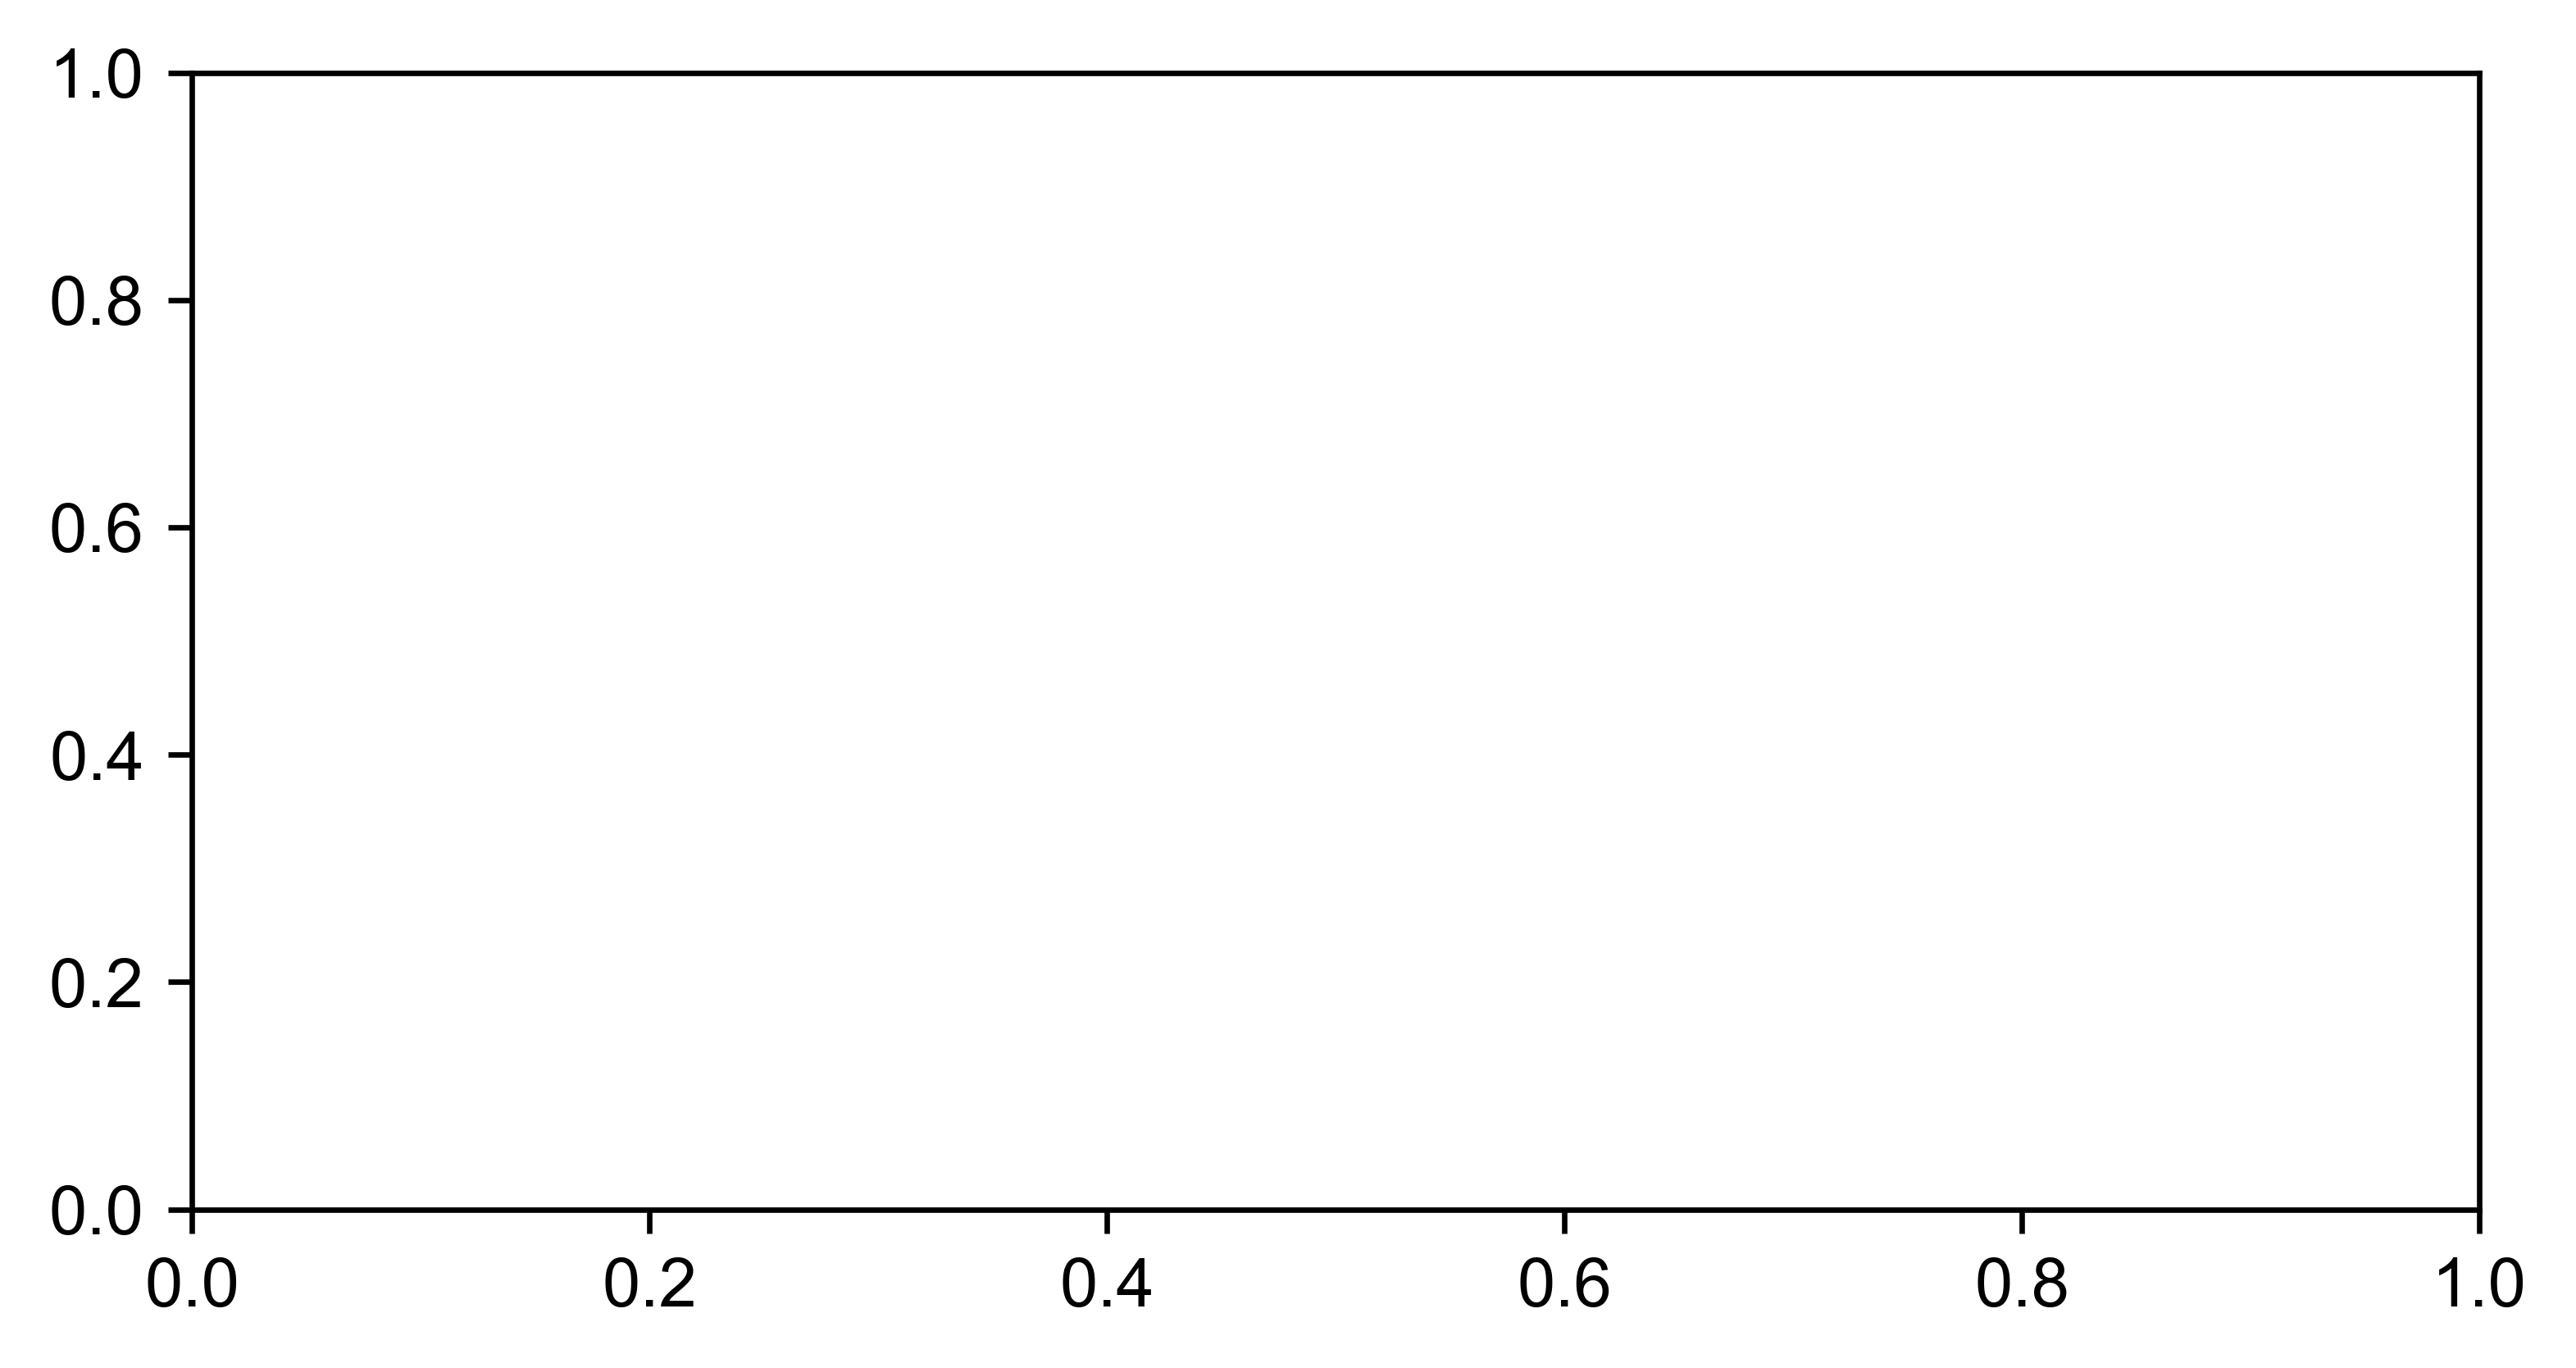

In [6]:

from locscale.include.emmer.ndimage.profile_tools import frequency_array
fig_raw, ax_raw = plt.subplots(1,1,figsize=(6,3), dpi=600)
feature_enhanced_curves = []
deepemhancer_curves = []
emready_curves = []
threshold_curves = []
for emdb_pdb, filelist_dict in new_input_files_emdb.items():
    emdb, pdb = emdb_pdb.split("_")
    filelist = [filelist_dict["mask_path"], filelist_dict["unsharpened_map_path"], filelist_dict["feature_enhanced_map_path"], \
                filelist_dict["deepemhancer_map_path"], filelist_dict["emready_map_path"]]
    mask_path, unsharpened_map_path, feature_enhanced_map_path, deepemhancer_map_path, emready_map_path = filelist
    difference_mask_path = filelist_dict["difference_mask_path"]
    recall_curves = compare_recall_curves(difference_mask_path, unsharpened_map_path, feature_enhanced_map_path, deepemhancer_map_path, emready_map_path)
    #unsharp_map, apix = load_map(unsharpened_map_path)

    thresholds = recall_curves[os.path.basename(feature_enhanced_map_path)][1]
    list_of_profiles_native = [recall_curves[os.path.basename(map_path)][0] for map_path in filelist[2:]]
    legends = ["Feature Enhanced", "DeepEMhancer", "EMready"]
    fig = pretty_plot_fsc_curve(thresholds, list_of_profiles_native, legends=legends, figsize_cm=(8,8), fontsize=10,linewidth=1, \
                                marker="o", markersize=5,font="Helvetica",fontscale=1, showlegend=True, showPoints=False, \
                                alpha=1, variation=None, yticks=None, ylims=None, xlims=None, crop_freq=None, labelsize=None, title=None)
    figsavepath = os.path.join(os.path.dirname(unsharpened_map_path), f"{emdb_pdb}_recall_curves_DE_wide.pdf")
    fig.savefig(figsavepath, dpi=600, bbox_inches="tight")
    plt.close(fig)
    # add figure to the raw plot
    feature_enhanced_curves.append(recall_curves[os.path.basename(feature_enhanced_map_path)])
    deepemhancer_curves.append(recall_curves[os.path.basename(deepemhancer_map_path)])
    emready_curves.append(recall_curves[os.path.basename(emready_map_path)])
    threshold_curves.append(thresholds)





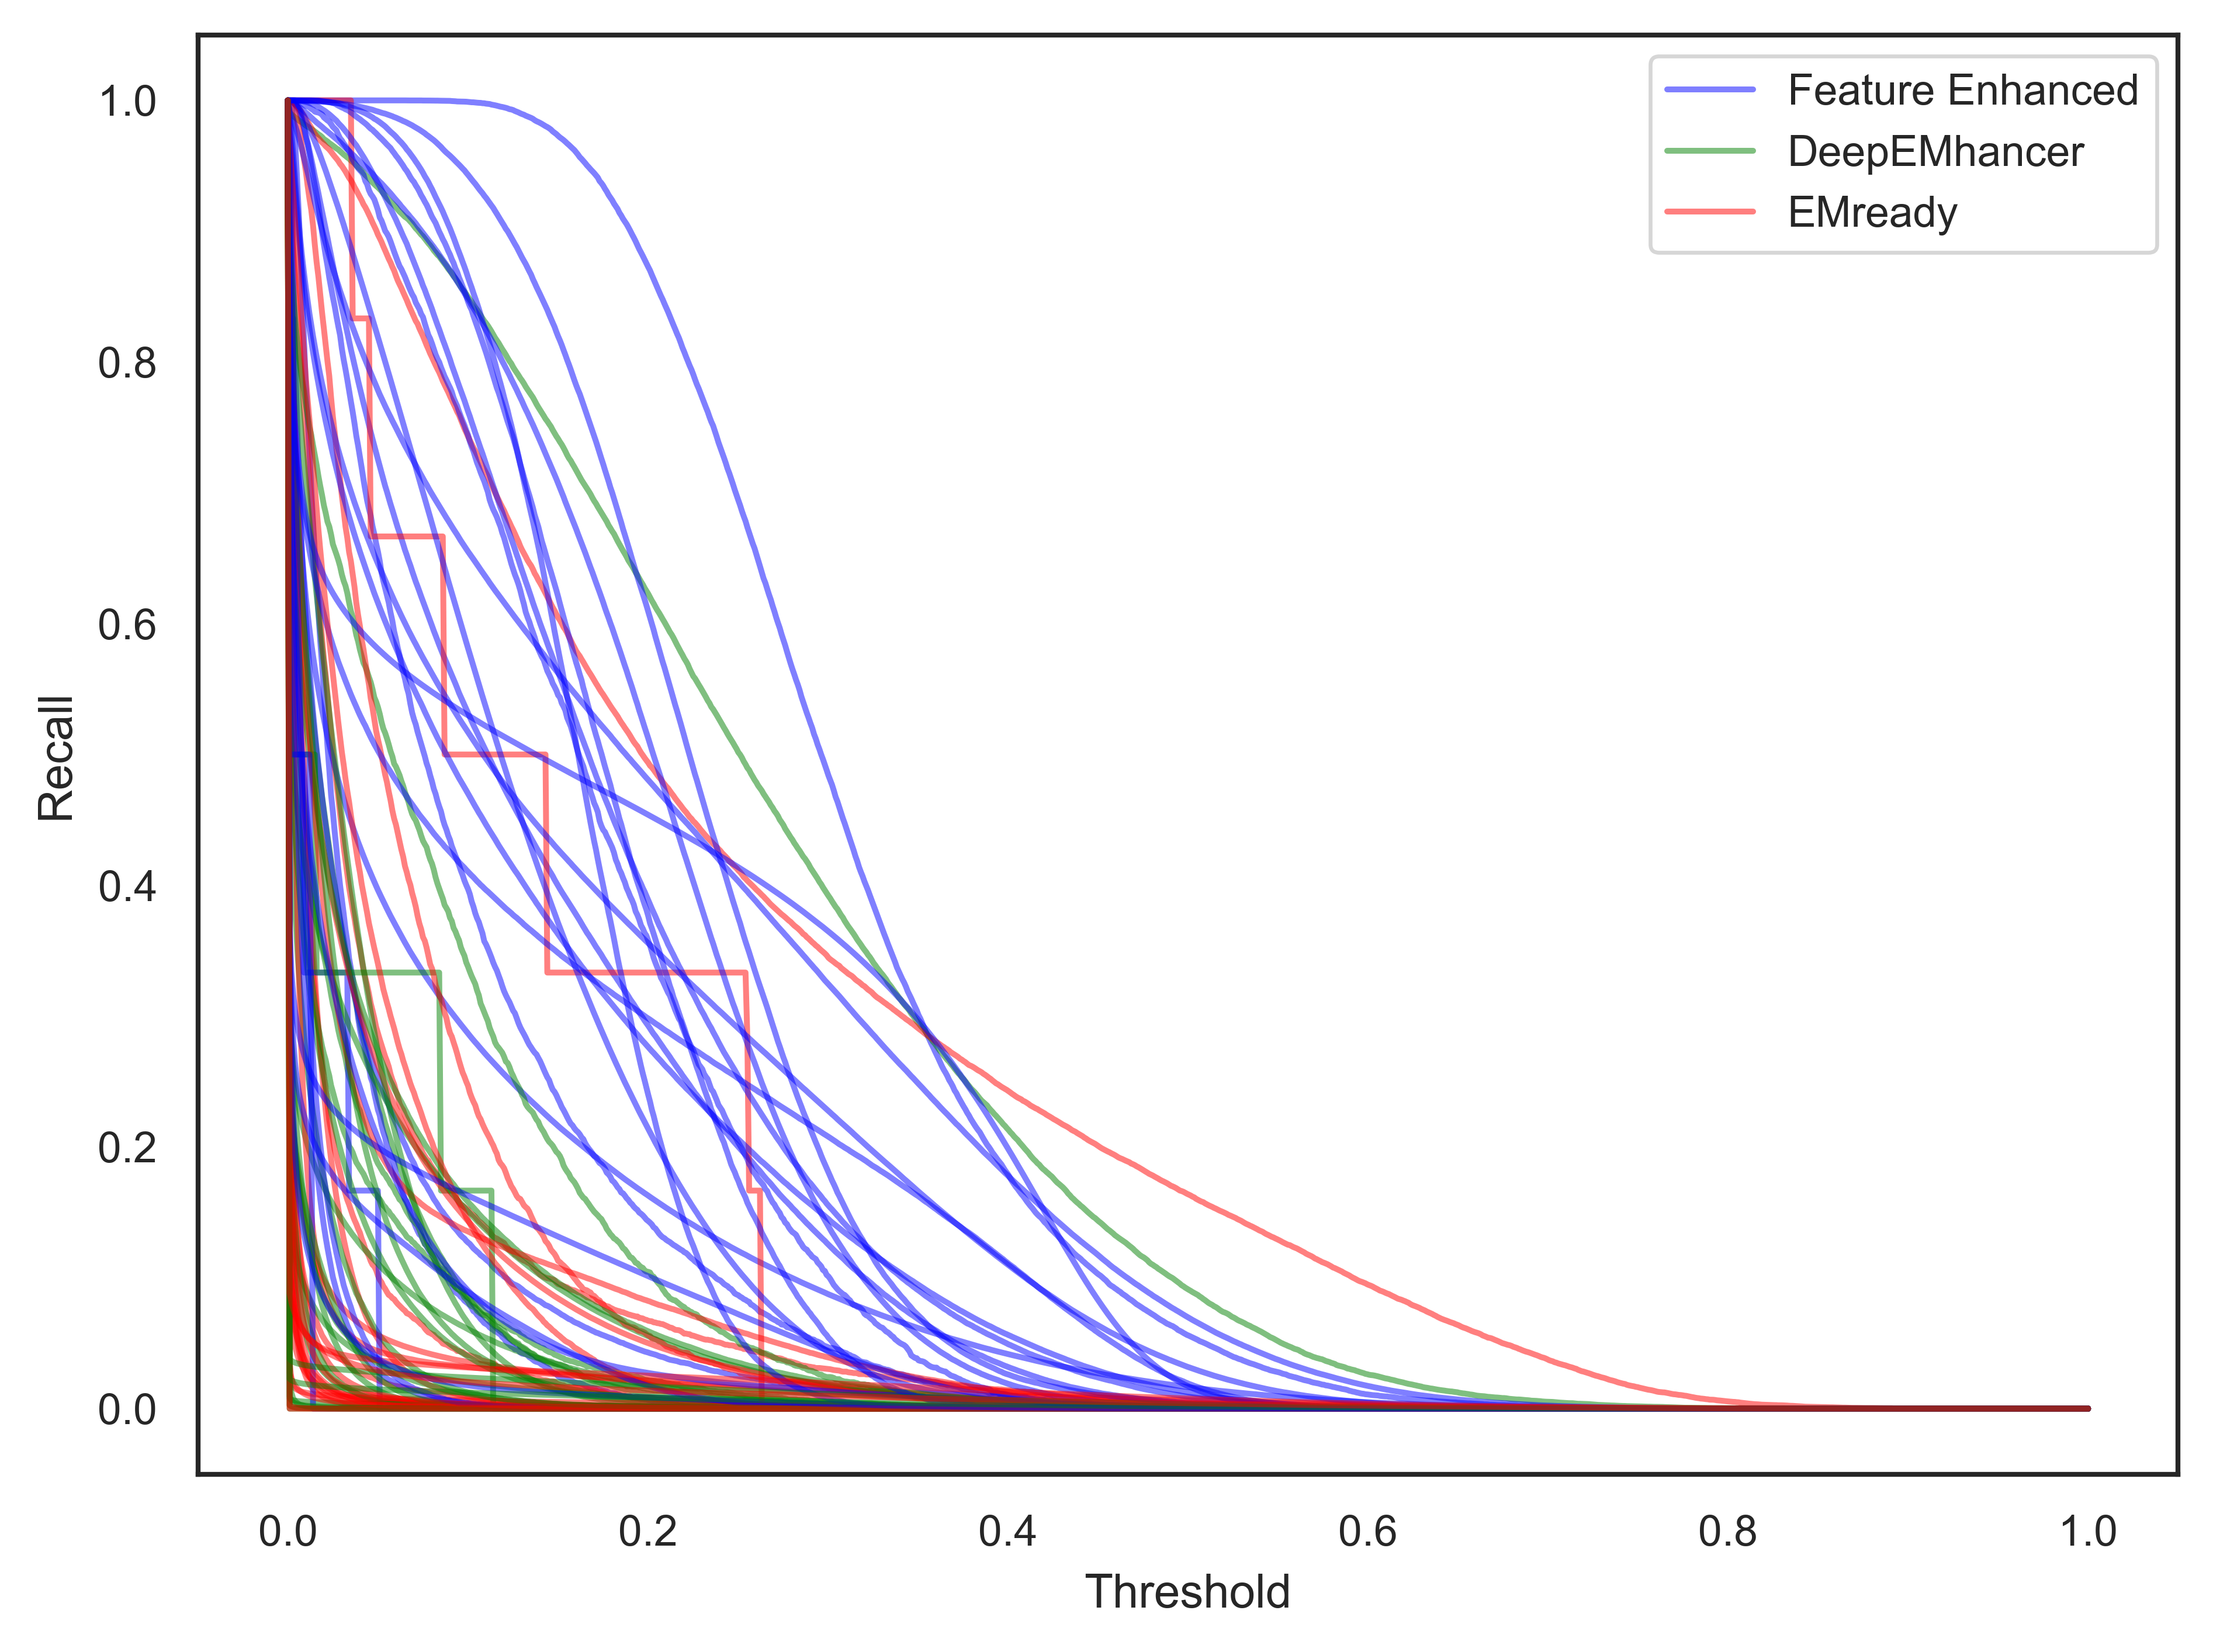

In [7]:
fig_raw, ax_raw = plt.subplots(1,1, dpi=600)
for i in range(len(feature_enhanced_curves)):
    freq = threshold_curves[i]
    ax_raw.plot(freq, feature_enhanced_curves[i][0], label="Feature Enhanced", color="blue", alpha=0.5)
    ax_raw.plot(freq, deepemhancer_curves[i][0], label="DeepEMhancer", color="green", alpha=0.5)
    ax_raw.plot(freq, emready_curves[i][0], label="EMready", color="red", alpha=0.5)
    
ax_raw.set_xlabel("Threshold")
ax_raw.set_ylabel("Recall")
# hide legend
ax_raw.legend(["Feature Enhanced", "DeepEMhancer", "EMready"], loc="best")
plt.tight_layout()
figsavepath = os.path.join(parent_dir, "outputs", "recall_curves_all_DE_wide_diffmask.eps")
#plt.savefig(figsavepath, dpi=600, bbox_inches="tight")

In [8]:
area_under_curve = {}
for i in range(len(feature_enhanced_curves)):
    # fe_area = np.trapz(feature_enhanced_curves[i][0], feature_enhanced_curves[i][1])
    # deepemhancer_area = np.trapz(deepemhancer_curves[i][0], deepemhancer_curves[i][1])
    # emready_area = np.trapz(emready_curves[i][0], emready_curves[i][1])
    fe_area = np.mean(feature_enhanced_curves[i][0])
    deepemhancer_area = np.mean(deepemhancer_curves[i][0])
    emready_area = np.mean(emready_curves[i][0])
    area_under_curve[list(input_files_emdb.keys())[i]] = [fe_area, deepemhancer_area, emready_area]


In [9]:
def emdb_to_pdb(emdb_id):
    import requests    
    url = f"https://www.ebi.ac.uk/emdb/api/entry/{emdb_id}"
    response = requests.get(url)
    data = response.json()
    try:
        pdb_id = data["crossreferences"]["pdb_list"]["pdb_reference"][0]["pdb_id"]

        return pdb_id    
    except (KeyError, IndexError):
        print(f"No PDB ID found for EMDB ID {emdb_id}")
        return "none"

print(emdb_to_pdb(3061))
emdb_contains_membrane = lambda emdb_id: os.path.exists(f"/home/abharadwaj1/papers/elife_paper/figure_information/data/pdb_containing_membrane/{emdb_to_pdb(emdb_id)}.pdb")


5a63


In [10]:
emdb_ids_in_this_study_with_membrane = [emdb for emdb in new_input_files_emdb.keys() if emdb_contains_membrane(emdb.split("_")[0])]
area_under_curve_df_membrane = {}
for emdb in emdb_ids_in_this_study_with_membrane:
    area_under_curve_df_membrane[emdb] = area_under_curve[emdb]
area_under_curve_df_no_membrane = {}
for emdb in new_input_files_emdb:
    try:
        if emdb not in emdb_ids_in_this_study_with_membrane:
            area_under_curve_df_no_membrane[emdb] = area_under_curve[emdb]
    except KeyError:
        print(f"KeyError for {emdb}, skipping...")
        continue         

KeyError for 39109_xxxx, skipping...


/home/abharadwaj1/miniconda3/envs/locscale2/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 7.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/abharadwaj1/miniconda3/envs/locscale2/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 11.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


Figure saved at /home/abharadwaj1/papers/elife_paper/figure_information/outputs/recall_curve_area_boxplot_DE_wide_diffmask.pdf


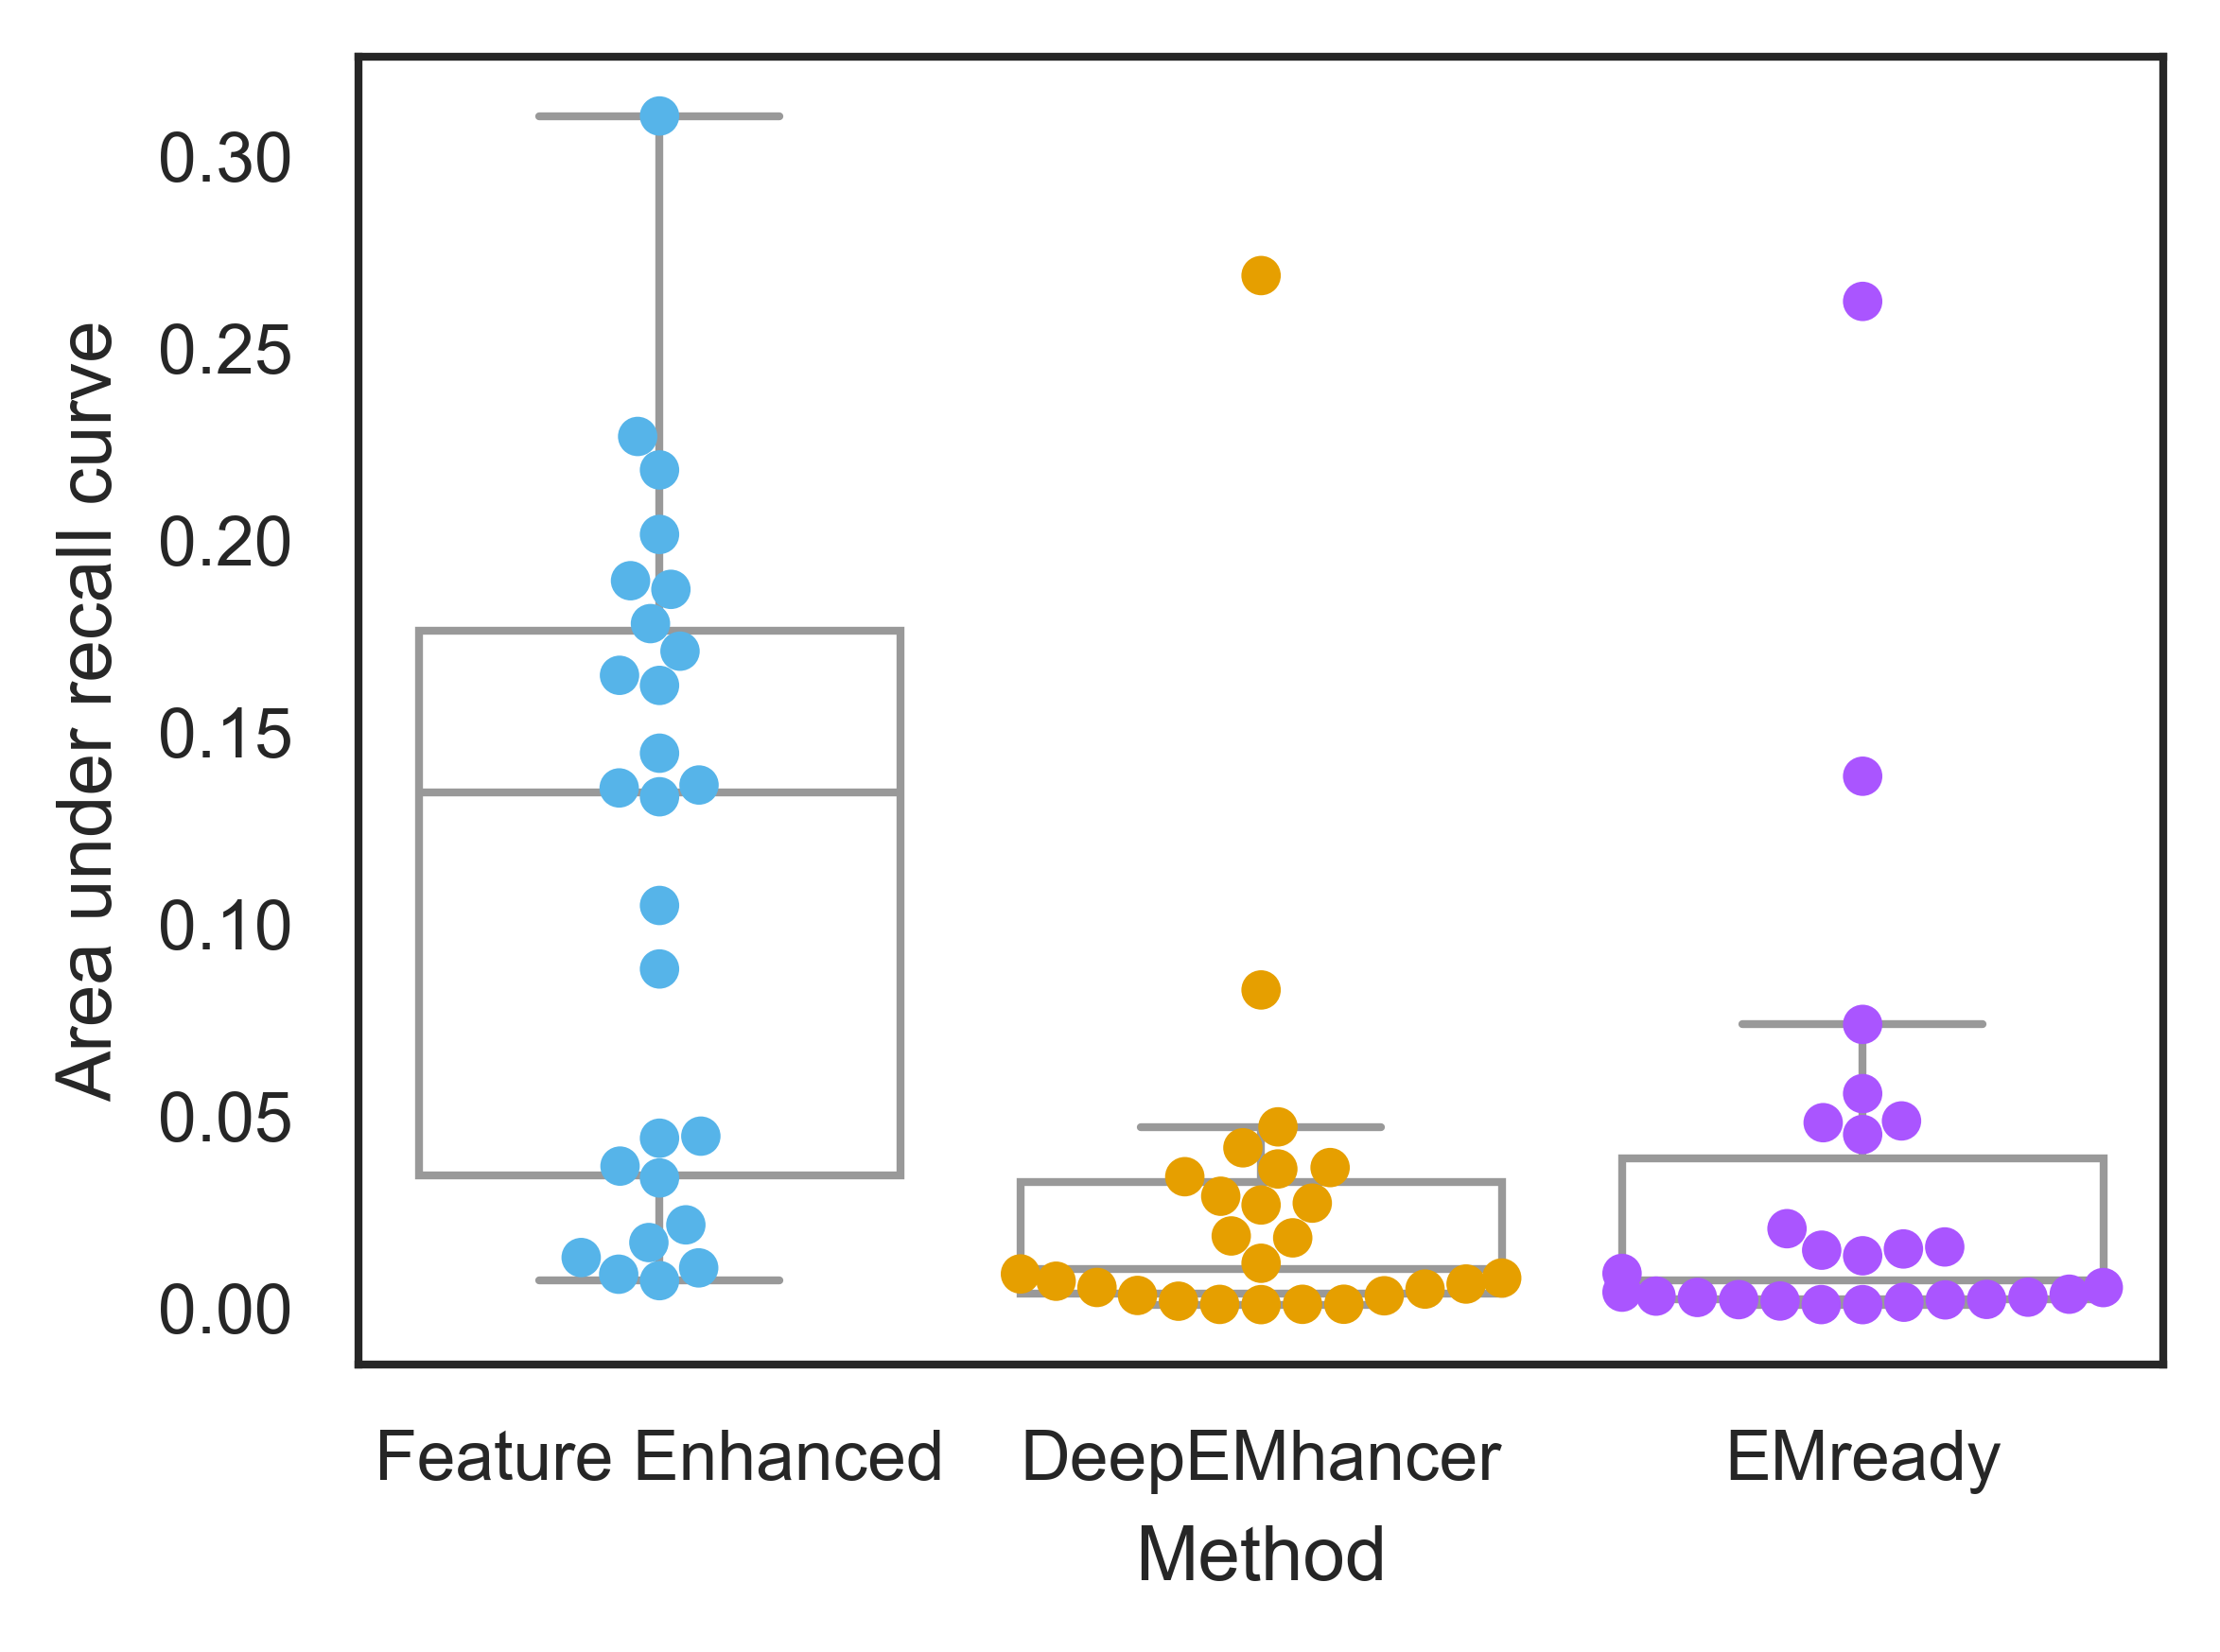

In [11]:
import pandas as pd
area_under_curve_df = pd.DataFrame.from_dict(area_under_curve, orient="index", columns=["Feature Enhanced", "DeepEMhancer", "EMready"])

#fig, ax = plt.subplots(1,1, dpi=600, figsize=(6,3))
#sns.boxplot(data=area_under_curve_df, ax=ax, color="white", linewidth=1)

# color dots based on membrane presence
area_under_curve_df["Membrane"] = area_under_curve_df.index.map(lambda x: "Membrane" if x in emdb_ids_in_this_study_with_membrane else "No Membrane")
#sns.stripplot(data=area_under_curve_df, ax=ax, alpha=0.5, hue="Membrane")
#sns.swarmplot(data=area_under_curve_df_membrane, ax=ax, color="blue", alpha=0.5)
#sns.swarmplot(data=area_under_curve_df_no_membrane, ax=ax, color="black", alpha=0.5)

# Melt the DataFrame into long-form
area_under_curve_long = area_under_curve_df.melt(
    id_vars=["Membrane"], 
    var_name="Method", 
    value_name="Area",
    ignore_index=False
)

# Create the boxplot
fig, ax = plt.subplots(1, 1, dpi=600, figsize=(4, 3))
sns.boxplot(data=area_under_curve_long, x="Method", y="Area", ax=ax, color="white", linewidth=1, showfliers=False)

# Add the swarmplot with custom colors
#palette = {"Membrane": "blue", "No Membrane": "grey"}
##  Feature enhanced : "#56b4e9"
## Deepemhancer: "#e69f00"
## EMReady "#aa55ff"
palette = {"Feature Enhanced": "#56b4e9", 
              "DeepEMhancer": "#e69f00", 
              "EMready": "#aa55ff"}

sns.swarmplot(data=area_under_curve_long, x="Method", y="Area",alpha=1, ax=ax, hue="Method", palette=palette)# hue="Membrane", palette=palette, dodge=False)

ax.set_ylabel("Area under recall curve")
#ax.set_xlabel("Method")
plt.tight_layout()
figsavepath = os.path.join(parent_dir, "outputs", "recall_curve_area_boxplot_DE_wide_diffmask.pdf")
#plt.savefig(figsavepath, dpi=600, bbox_inches="tight")
print(f"Figure saved at {figsavepath}")
# save data 
#area_under_curve_df.to_csv(os.path.join(parent_dir, "outputs", "recall_curve_area_DE_wide_diffmask.csv"))


In [12]:
print(area_under_curve_df.columns)

Index(['Feature Enhanced', 'DeepEMhancer', 'EMready', 'Membrane'], dtype='object')


In [13]:
# run permutation tests to compute the significance of the differences between the methods
from scipy.stats import permutation_test

# test between feature enhanced and deepemhancer
def run_permutation_test(data1, data2, num_permutations=10000):
    def statistic(x, y):
        return np.mean(x) - np.mean(y)

    result = permutation_test((data1, data2), statistic, n_resamples=num_permutations, alternative='two-sided')
    # print 
    print(f"pvalue: {result.pvalue}, statistic: {result.statistic} significance: {result.pvalue < 0.05}")
    return result

results = {}

fe_area = area_under_curve_df["Feature Enhanced"]
deepemhancer_area = area_under_curve_df["DeepEMhancer"]
emready_area = area_under_curve_df["EMready"]

results[list(input_files_emdb.keys())[i]] = {
    "Feature Enhanced vs DeepEMhancer": run_permutation_test(fe_area, deepemhancer_area),
    "Feature Enhanced vs EMready": run_permutation_test(fe_area, emready_area),
    "DeepEMhancer vs EMready": run_permutation_test(deepemhancer_area, emready_area)
}


pvalue: 0.00019998000199980003, statistic: 0.08687584397563167 significance: True
pvalue: 0.00039996000399960006, statistic: 0.08442239571560656 significance: True
pvalue: 0.8731126887311269, statistic: -0.002453448260025113 significance: False


In [14]:
from locscale.include.emmer.ndimage.map_tools import get_atomic_model_mask, find_unmodelled_mask_region
from locscale.include.emmer.ndimage.map_utils import load_map, save_as_mrc
from locscale.include.emmer.pdb.pdb_utils import get_gemmi_st_from_id

from sklearn.metrics import precision_recall_curve
# unsharpened_map_positive_values = unsharpened_map.copy()
# unsharpened_map_positive_values[unsharpened_map_positive_values < 0] = 0
# feature_enhanced_map_positive_values = feature_enhanced_map.copy()
# feature_enhanced_map_positive_values[feature_enhanced_map_positive_values < 0] = 0
# deepemhancer_map_positive_values = deepemhancer_map.copy()
# deepemhancer_map_positive_values[deepemhancer_map_positive_values < 0] = 0
# emready_map_positive_values = emready_map.copy()
# emready_map_positive_values[emready_map_positive_values < 0] = 0

# # rescale the maps to range 0 to 1
# unsharpened_map_positive_values_rescale = (unsharpened_map_positive_values - np.min(unsharpened_map_positive_values)) / (np.max(unsharpened_map_positive_values) - np.min(unsharpened_map_positive_values))
# feature_enhanced_map_positive_values_rescale = (feature_enhanced_map_positive_values - np.min(feature_enhanced_map_positive_values)) / (np.max(feature_enhanced_map_positive_values) - np.min(feature_enhanced_map_positive_values))
# deepemhancer_map_positive_values_rescale = (deepemhancer_map_positive_values - np.min(deepemhancer_map_positive_values)) / (np.max(deepemhancer_map_positive_values) - np.min(deepemhancer_map_positive_values))
# emready_map_positive_values_rescale = (emready_map_positive_values - np.min(emready_map_positive_values)) / (np.max(emready_map_positive_values) - np.min(emready_map_positive_values))

# precision_unsharp, recalls_unsharp, threshold_unsharp = precision_recall_curve(mask_binarized.flatten(), unsharpened_map_positive_values_rescale.flatten())
# precision_feature, recalls_feature, threshold_feature = precision_recall_curve(mask_binarized.flatten(), feature_enhanced_map_positive_values_rescale.flatten())
# precision_deep, recalls_deep, threshold_deep = precision_recall_curve(mask_binarized.flatten(), deepemhancer_map_positive_values_rescale.flatten())
# precision_emready, recalls_emready, threshold_emready = precision_recall_curve(mask_binarized.flatten(), emready_map_positive_values_rescale.flatten())

pdb_path = "/home/abharadwaj1/papers/elife_paper/figure_information/data/deposited_atomic_models/PDB_6oa9_unrefined_shifted_servalcat_refined_shifted_servalcat_refined.pdb"

difference_mask_path = os.path.join(os.path.dirname(unsharpened_map_path), f"0665_6oa9_difference_mask.mrc")
if not os.path.exists(difference_mask_path):
    difference_mask = find_unmodelled_mask_region(fdr_mask_path=mask_path, pdb_path=pdb_path)
    _ , apix = load_map(unsharpened_map_path)
    save_as_mrc(difference_mask,difference_mask_path , apix=apix)
    
recall_curves_with_diffmask = compare_recall_curves(difference_mask_path, unsharpened_map_path, feature_enhanced_map_path, deepemhancer_map_path, emready_map_path)
recall_curves = compare_recall_curves(mask_path, unsharpened_map_path, feature_enhanced_map_path, deepemhancer_map_path, emready_map_path)
unsharp_map, apix = load_map(unsharpened_map_path)



(288, 288, 288)


/tmp/ipykernel_12206/755534174.py:194: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(recall_new_range, thresholds_new_range)


(288, 288, 288)


/tmp/ipykernel_12206/755534174.py:194: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(recall_new_range, thresholds_new_range)


(288, 288, 288)


...

/tmp/ipykernel_12206/755534174.py:194: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(recall_new_range, thresholds_new_range)


(288, 288, 288)


/tmp/ipykernel_12206/755534174.py:194: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(recall_new_range, thresholds_new_range)


(288, 288, 288)


/tmp/ipykernel_12206/755534174.py:194: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(recall_new_range, thresholds_new_range)


/tmp/ipykernel_12206/1372768029.py:56: RuntimeWarning: divide by zero encountered in scalar divide
  ax2.set_xticklabels([round(1/x,1) for x in ax1.get_xticks()])


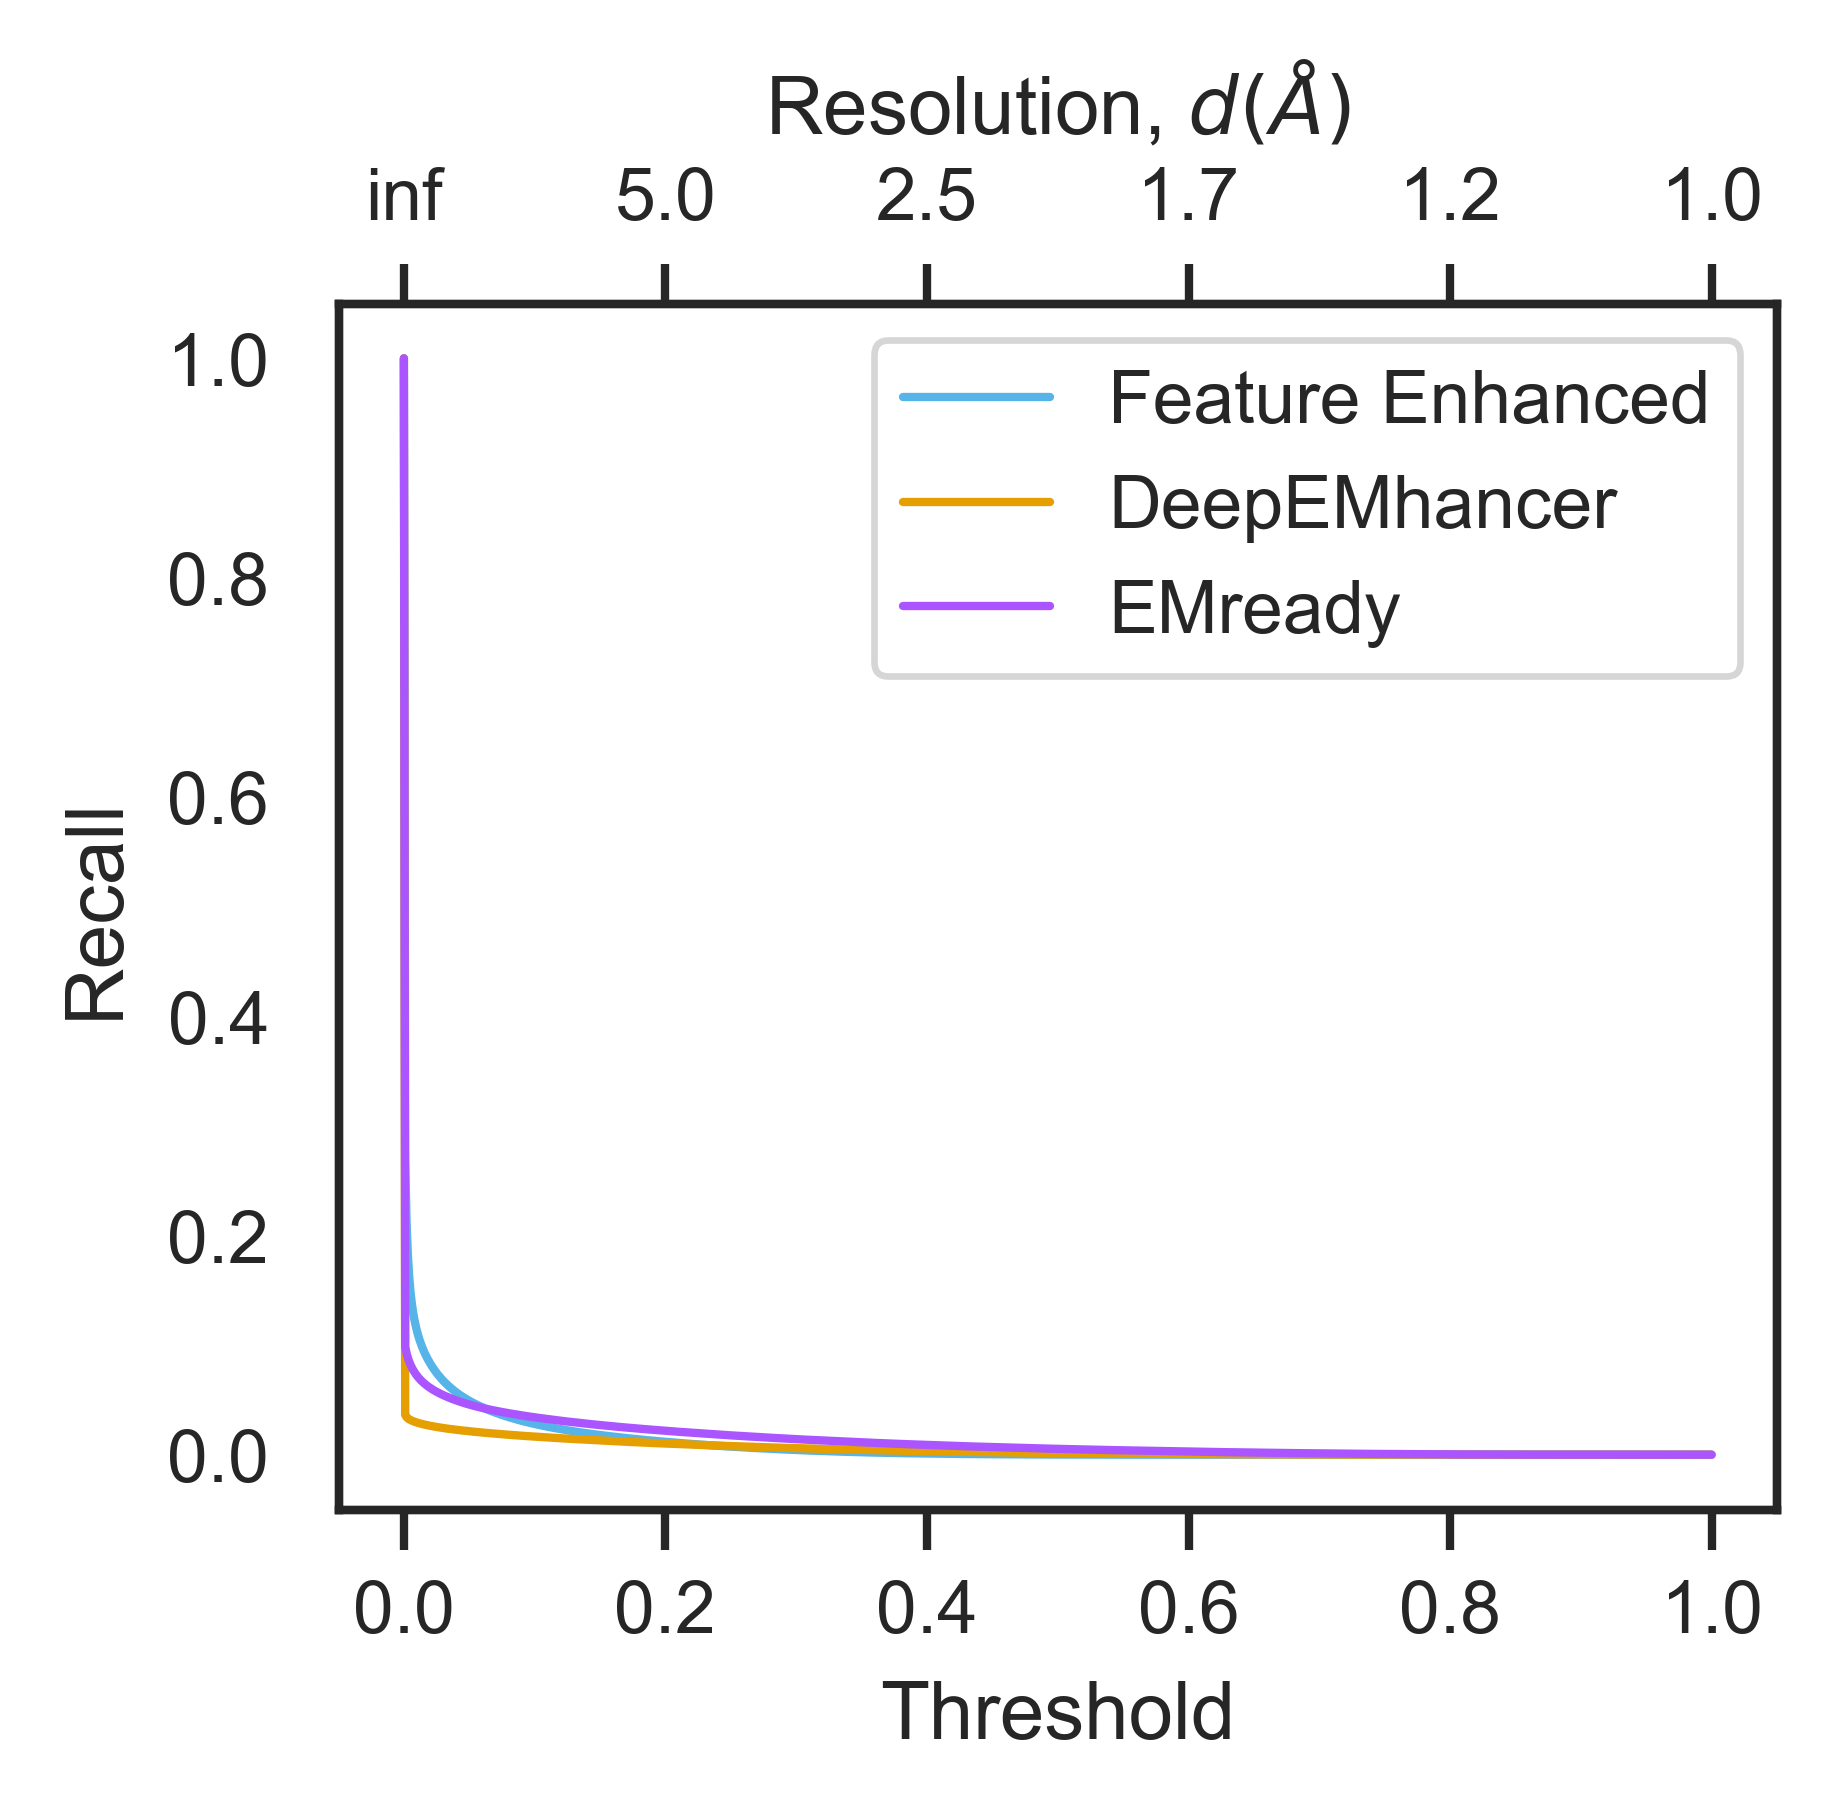

In [15]:
filelist = [mask_path, unsharpened_map_path, feature_enhanced_map_path, deepemhancer_map_path, emready_map_path]
thresholds = recall_curves[os.path.basename(feature_enhanced_map_path)][1]
list_of_profiles_native = [recall_curves[os.path.basename(map_path)][0] for map_path in filelist[2:]]
legends = ["Feature Enhanced", "DeepEMhancer", "EMready"]
fig_0665 = pretty_plot_fsc_curve(thresholds, list_of_profiles_native, legends=legends, figsize_cm=(8,8), fontsize=10,linewidth=1, \
                            marker="o", markersize=5,font="Helvetica",fontscale=1, showlegend=True, showPoints=False, \
                            alpha=1, variation=None, yticks=None, ylims=None, xlims=None, crop_freq=None, labelsize=None, title=None)

ax_0665 = fig_0665.get_axes()[0]
ax_0665.set_xlabel("Threshold")
ax_0665.set_ylabel("Recall")

ax_0665.get_lines()[0].set_color("#56b4e9")
ax_0665.get_lines()[1].set_color("#e69f00")
ax_0665.get_lines()[2].set_color("#aa55ff")
ax_0665.legend(["Feature Enhanced", "DeepEMhancer", "EMready"])
figsavepath = os.path.join(os.path.dirname(unsharpened_map_path), f"recall_curves_EMD_0665_new.pdf")
fig_0665.savefig(figsavepath, dpi=600, bbox_inches="tight")
# dump data into csv file in the same folder
import pandas as pd
recall_data = {
    "Threshold": thresholds,
    "Feature Enhanced": list_of_profiles_native[0],
    "DeepEMhancer": list_of_profiles_native[1],
    "EMready": list_of_profiles_native[2]
}
recall_df = pd.DataFrame(recall_data)
recall_df.to_csv(os.path.join(os.path.dirname(unsharpened_map_path), f"recall_curves_EMD_0665_new.csv"), index=False)


/tmp/ipykernel_12206/1372768029.py:56: RuntimeWarning: divide by zero encountered in scalar divide
  ax2.set_xticklabels([round(1/x,1) for x in ax1.get_xticks()])


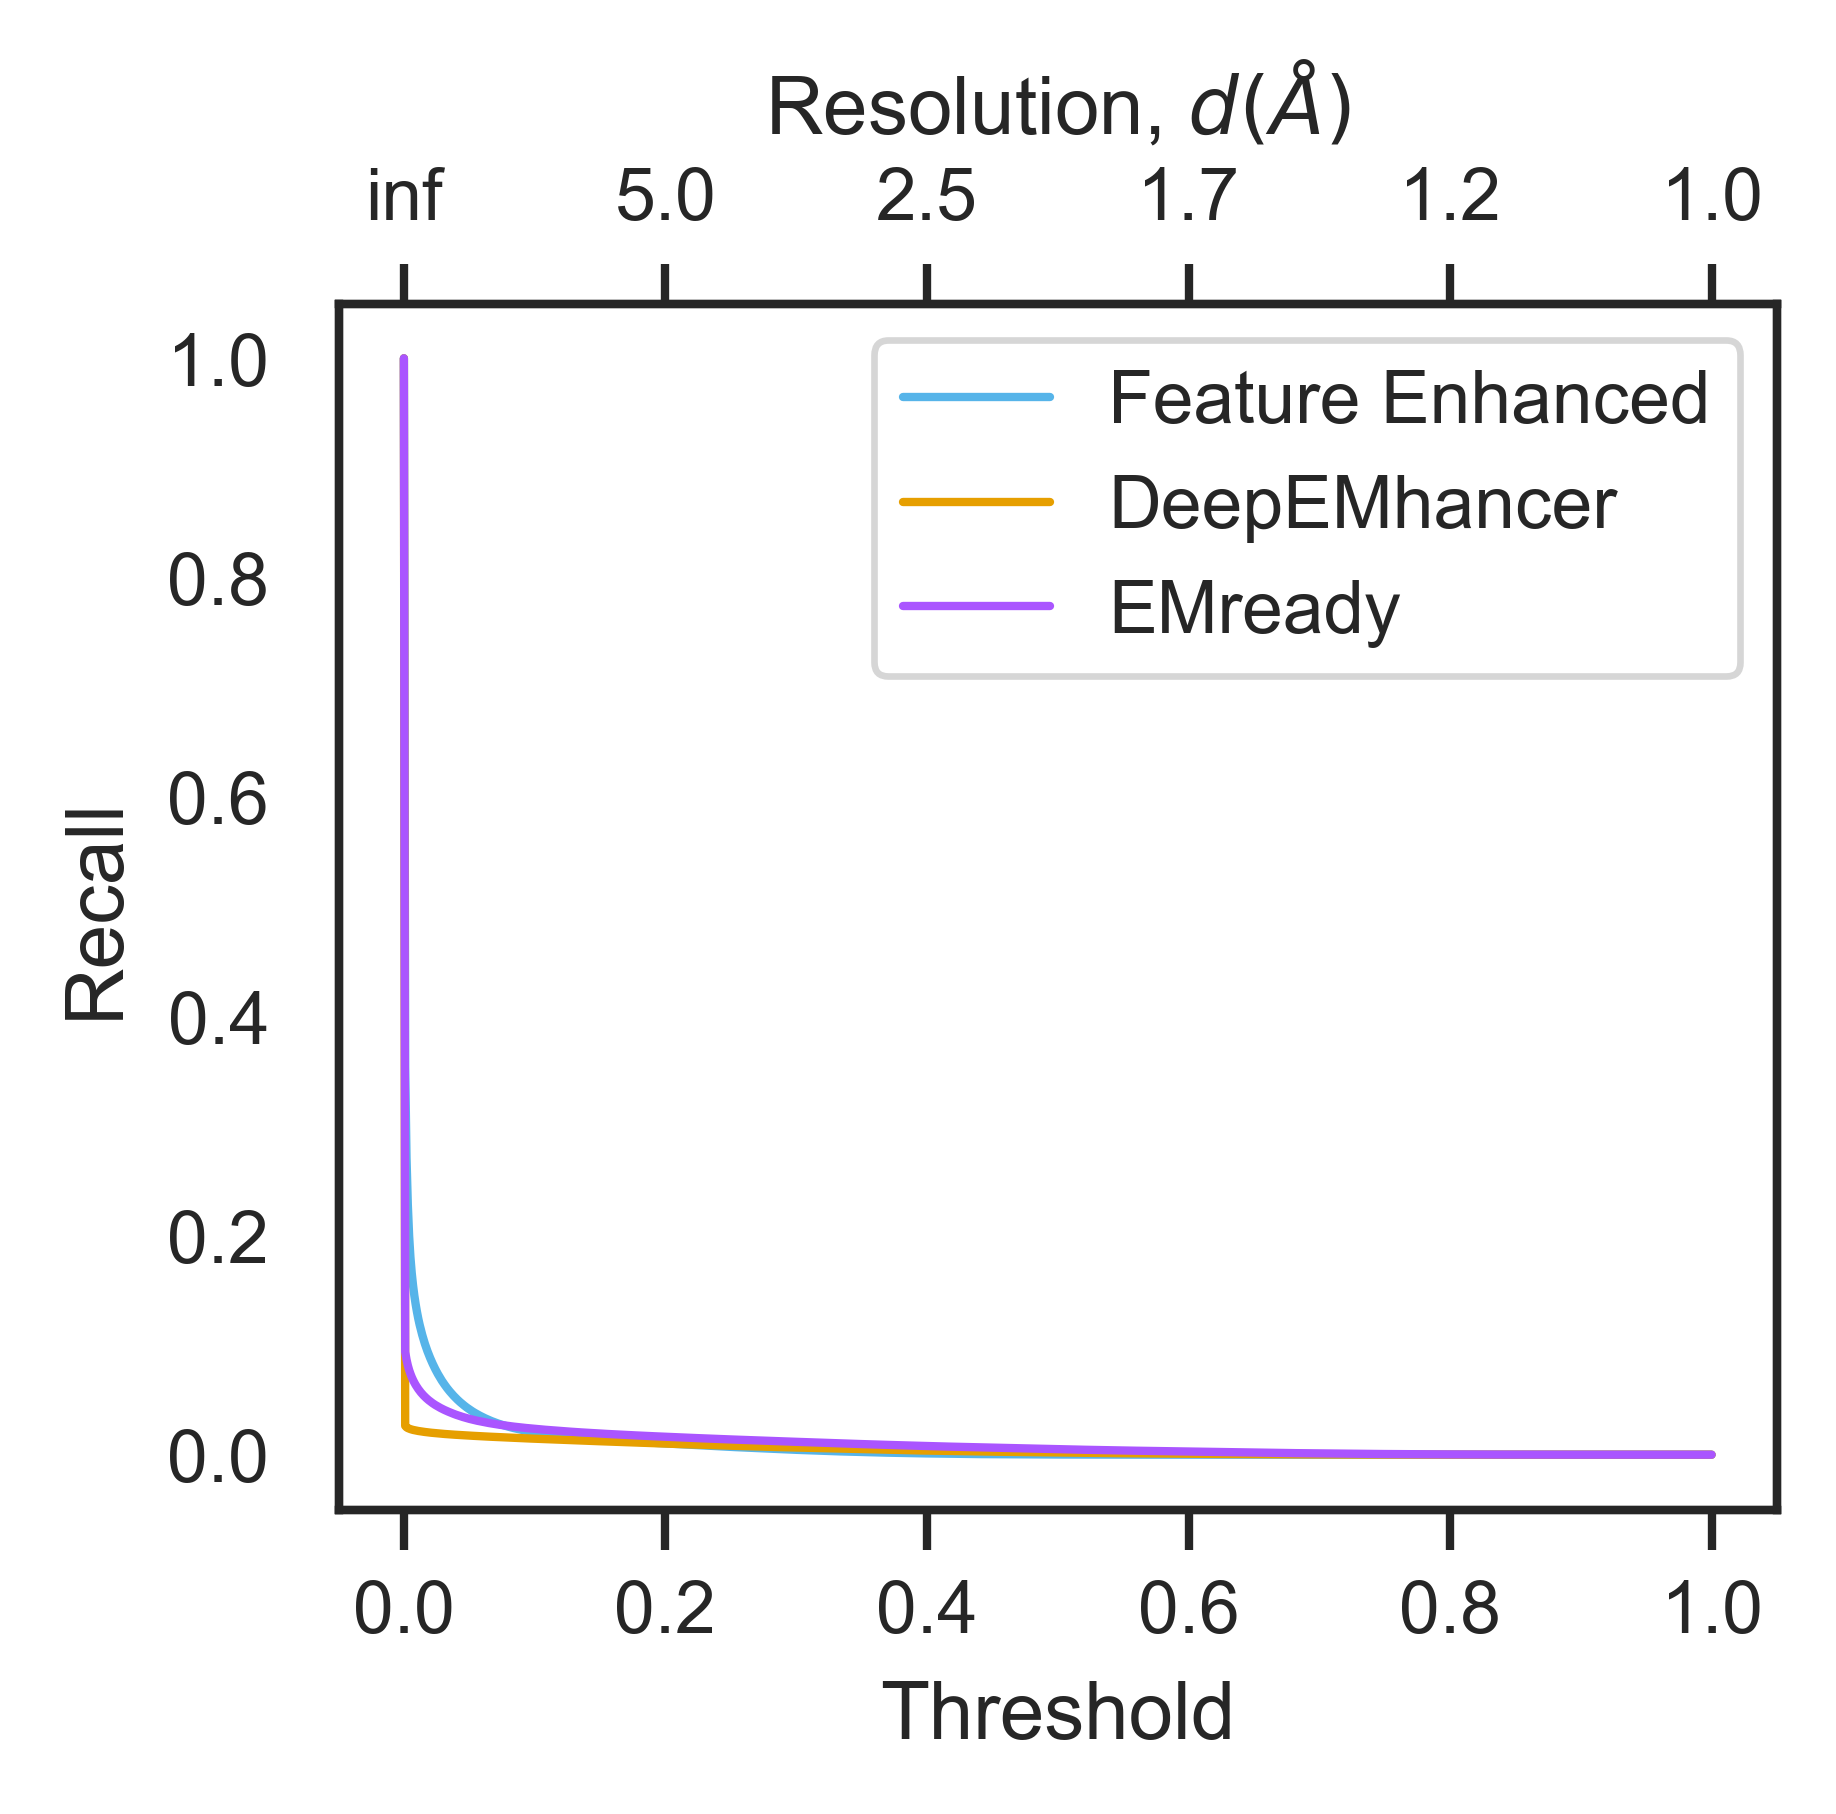

In [16]:
filelist = [mask_path, unsharpened_map_path, feature_enhanced_map_path, deepemhancer_map_path, emready_map_path]
thresholds = recall_curves_with_diffmask[os.path.basename(feature_enhanced_map_path)][1]
list_of_profiles_native = [recall_curves_with_diffmask[os.path.basename(map_path)][0] for map_path in filelist[2:]]
legends = ["Feature Enhanced", "DeepEMhancer", "EMready"]
fig_0665 = pretty_plot_fsc_curve(thresholds, list_of_profiles_native, legends=legends, figsize_cm=(8,8), fontsize=10,linewidth=1, \
                            marker="o", markersize=5,font="Helvetica",fontscale=1, showlegend=True, showPoints=False, \
                            alpha=1, variation=None, yticks=None, ylims=None, xlims=None, crop_freq=None, labelsize=None, title=None)

ax_0665 = fig_0665.get_axes()[0]
ax_0665.set_xlabel("Threshold")
ax_0665.set_ylabel("Recall")

ax_0665.get_lines()[0].set_color("#56b4e9")
ax_0665.get_lines()[1].set_color("#e69f00")
ax_0665.get_lines()[2].set_color("#aa55ff")
ax_0665.legend(["Feature Enhanced", "DeepEMhancer", "EMready"])
figsavepath = os.path.join(os.path.dirname(unsharpened_map_path), f"recall_curves_EMD_0665_new_with_diffmask.pdf")
fig_0665.savefig(figsavepath, dpi=600, bbox_inches="tight")
# dump data into csv file in the same folder
import pandas as pd
recall_data = {
    "Threshold": thresholds,
    "Feature Enhanced": list_of_profiles_native[0],
    "DeepEMhancer": list_of_profiles_native[1],
    "EMready": list_of_profiles_native[2]
}
recall_df = pd.DataFrame(recall_data)
recall_df.to_csv(os.path.join(os.path.dirname(unsharpened_map_path), f"recall_curves_EMD_0665_new_with_diffmask.csv"), index=False)


In [17]:
recall_df[(recall_df["Threshold"]>0.3-0.001)& (recall_df["Threshold"]<0.3+0.001)]

,Threshold,Feature Enhanced,DeepEMhancer,EMready
299,0.299299,0.004471,0.006502,0.011765
300,0.300300,0.004419,0.006474,0.011719


In [18]:
figsavepath

'/home/abharadwaj1/papers/elife_paper/figure_information/data/compute_cii_all_data/39109_xxxx/recall_curves_EMD_0665_new_with_diffmask.pdf'

In [19]:
# print the recall values at threshold 0.1, 0.2 and 0.3 for all maps 
thresholds = recall_curves[os.path.basename(feature_enhanced_map_path)][1]
recall_feature = recall_curves[os.path.basename(feature_enhanced_map_path)][0]
recall_deep = recall_curves[os.path.basename(deepemhancer_map_path)][0]
recall_emready = recall_curves[os.path.basename(emready_map_path)][0]

recall_feature_01 = recall_feature[100]
recall_feature_02 = recall_feature[200]
recall_feature_03 = recall_feature[300]

recall_deep_01 = recall_deep[100]
recall_deep_02 = recall_deep[200]
recall_deep_03 = recall_deep[300]

recall_emready_01 = recall_emready[100]
recall_emready_02 = recall_emready[200]
recall_emready_03 = recall_emready[300]
print("Recall values at thresholds 0.1, 0.2 and 0.3")
print(f"Feature Enhanced: {recall_feature_01}, {recall_feature_02}, {recall_feature_03}")
print(f"DeepEMhancer: {recall_deep_01}, {recall_deep_02}, {recall_deep_03}")
print(f"EMready: {recall_emready_01}, {recall_emready_02}, {recall_emready_03}")



Recall values at thresholds 0.1, 0.2 and 0.3
Feature Enhanced: 0.027989051180670067, 0.0117130946288359, 0.004249084789681782
DeepEMhancer: 0.01646224562644693, 0.010152940866537619, 0.005936729066436128
EMready: 0.034064301523404415, 0.021804198560370282, 0.014158440259880717


In [20]:
threshold_feature = recall_curves[os.path.basename(feature_enhanced_map_path)][1]
threshold_deep = recall_curves[os.path.basename(deepemhancer_map_path)][1]
threshold_emready = recall_curves[os.path.basename(emready_map_path)][1]

# check if the thresholds are the same
print("Thresholds are the same: ", np.allclose(threshold_feature, threshold_deep))
print("Thresholds are the same: ", np.allclose(threshold_feature, threshold_emready))

Thresholds are the same:  True
Thresholds are the same:  True


In [21]:
fig_0665 = pretty_plot_fsc_curve(threshold_unsharp, [recalls_feature, recalls_deep, recalls_emready], 
                                 legends=["Feature Enhanced", "DeepEMhancer", "EMready"], figsize_cm=(8,8), fontsize=10,linewidth=1, \
                                marker="o", markersize=5,font="Helvetica",fontscale=1, showlegend=True, showPoints=False, \
                                alpha=1, variation=None, yticks=None, ylims=None, xlims=None, crop_freq=None, labelsize=None, title=None)

# change X axis to threshold
ax_0665 = fig_0665.get_axes()[0]
ax_0665.set_xlabel("Threshold")
ax_0665.set_ylabel("Recall")
ax_0665.set_title("EMD-0665")
# figsavepath = os.path.join(parent_dir, "outputs", "emd_0665_recall_curves.eps")
# fig_0665.savefig(figsavepath, dpi=600, bbox_inches="tight")


NameError: name 'threshold_unsharp' is not defined

In [ ]:
plt.plot(threshold_unsharp, recalls_unsharp[:-1], label="Recall Unsharp")
plt.plot(threshold_unsharp, precision_unsharp[:-1], label="Precision Unsharp")
plt.legend()
plt.show()


In [ ]:
plt.plot(threshold_feature, recalls_feature[:-1], label="Recall Feature")
plt.plot(threshold_feature, precision_feature[:-1], label="Precision Feature")
plt.legend()
plt.show()

In [ ]:
plt.plot(threshold_deep, recalls_deep[:-1], label="Recall DeepEM")
plt.plot(threshold_deep, precision_deep[:-1], label="Precision DeepEM")
plt.legend()
plt.show()

In [ ]:
plt.plot(threshold_emready, recalls_emready[:-1], label="Recall EMReady")
plt.plot(threshold_emready, precision_emready[:-1], label="Precision EMReady")
plt.legend()
plt.show()


In [ ]:
index_when_unsharp_precision_1 = np.where(precision_unsharp[:-1] == 1)[0][0]
index_when_feature_precision_1 = np.where(precision_feature[:-1] == 1)[0][0]
index_when_deep_precision_1 = np.where(precision_deep[:-1] == 1)[0][0]
index_when_emready_precision_1 = np.where(precision_emready[:-1] == 1)[0][0]

threshold_unsharp_when_precision_1 = threshold_unsharp[index_when_unsharp_precision_1]
threshold_feature_when_precision_1 = threshold_feature[index_when_feature_precision_1]
threshold_deep_when_precision_1 = threshold_deep[index_when_deep_precision_1]
threshold_emready_when_precision_1 = threshold_emready[index_when_emready_precision_1]

plt.plot(threshold_unsharp, recalls_unsharp[:-1], label="Recall Unsharp")
plt.plot(threshold_unsharp, precision_unsharp[:-1], label="Precision Unsharp")
plt.axvline(x=threshold_unsharp_when_precision_1, color="red", linestyle="--")
plt.legend()


In [ ]:
plt.plot(threshold_feature, recalls_feature[:-1], label="Recall Feature")
plt.plot(threshold_feature, precision_feature[:-1], label="Precision Feature")
plt.axvline(x=threshold_feature_when_precision_1, color="red", linestyle="--")
plt.legend()


In [ ]:
plt.plot(threshold_deep, recalls_deep[:-1], label="Recall DeepEM")
plt.plot(threshold_deep, precision_deep[:-1], label="Precision DeepEM")
plt.axvline(x=threshold_deep_when_precision_1, color="red", linestyle="--")
plt.legend()


In [ ]:
plt.plot(threshold_emready, recalls_emready[:-1], label="Recall EMReady")
plt.plot(threshold_emready, precision_emready[:-1], label="Precision EMReady")
plt.axvline(x=threshold_emready_when_precision_1, color="red", linestyle="--")
plt.legend()
